# GROUP -3 :- Harish Deepak
## Goal : To predict how likely individuals are to receive their H1N1 and seasonal flu vaccines

## 1. Importing Necessary Libraries

In [ ]:
# Importing necessary Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Optional
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

## 2.Loading Data (Data type, missing value, exemplary rows)

In [ ]:
features_url = "http://guoyuanxiong.github.io/teaching/Vaccine/features.csv"
labels_url = "http://guoyuanxiong.github.io/teaching/Vaccine/labels.csv"

features = pd.read_csv(features_url)
labels = pd.read_csv(labels_url)

df = features.merge(labels, on="respondent_id", how="inner")
# 1. Row and Column Numbers
print("=== Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 2. Data Types
print("\n=== Data Types ===")
print(df.dtypes)

# 3. Missing Values
print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Count": missing, "Percent (%)": missing_pct})
missing_df = missing_df[missing_df["Count"] > 0].sort_values("Count", ascending=False)
print(missing_df)
print(f"\nTotal columns with missing values: {len(missing_df)}")

# 4. Exemplary Rows
print("\n=== First 5 Rows ===")
print(df.head())

=== Shape ===
Rows: 26707, Columns: 38

=== Data Types ===
respondent_id                    int64
h1n1_concern                   float64
h1n1_knowledge                 float64
behavioral_antiviral_meds      float64
behavioral_avoidance           float64
behavioral_face_mask           float64
behavioral_wash_hands          float64
behavioral_large_gatherings    float64
behavioral_outside_home        float64
behavioral_touch_face          float64
doctor_recc_h1n1               float64
doctor_recc_seasonal           float64
chronic_med_condition          float64
child_under_6_months           float64
health_worker                  float64
health_insurance               float64
opinion_h1n1_vacc_effective    float64
opinion_h1n1_risk              float64
opinion_h1n1_sick_from_vacc    float64
opinion_seas_vacc_effective    float64
opinion_seas_risk              float64
opinion_seas_sick_from_vacc    float64
age_group                       object
education                       object
race 

## 3. Data Understanding/EDA

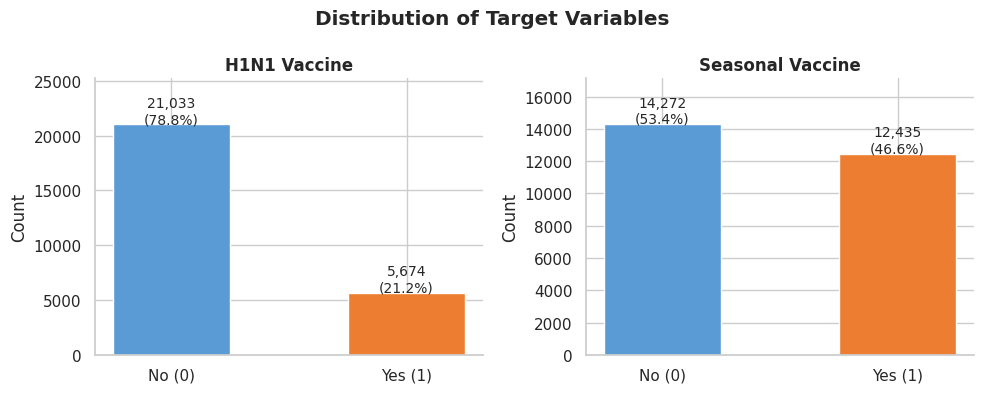

=== Phi Coefficient ===
Chi-square = 3796.8642, p-value = 0, Phi coefficient = 0.3771

Joint distribution (counts):
seasonal_vaccine      0     1
h1n1_vaccine                 
0                 13295  7738
1                   977  4697


In [ ]:
# 3.1 Distributions of the Two Target Variables

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Distribution of Target Variables", fontweight="bold")

for ax, col, title in zip(axes,
                           ["h1n1_vaccine", "seasonal_vaccine"],
                           ["H1N1 Vaccine", "Seasonal Vaccine"]):
    counts = df[col].value_counts().sort_index()
    ax.bar(["No (0)", "Yes (1)"], counts.values, color=["#5B9BD5", "#ED7D31"], width=0.5)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 100, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=10)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_ylim(0, max(counts.values) * 1.2)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig1_target_distributions.png", bbox_inches="tight")
plt.show()

# Phi Coefficient Between the Two Target Variables

contingency = pd.crosstab(df["h1n1_vaccine"], df["seasonal_vaccine"])
chi2, p, _, _ = chi2_contingency(contingency)
phi = np.sqrt(chi2 / len(df))

print("=== Phi Coefficient ===")
print(f"Chi-square = {chi2:.4f}, p-value = {p:.4g}, Phi coefficient = {phi:.4f}")
print()
print("Joint distribution (counts):")
print(contingency)

### Observations on Target Variables (H1N1 vs Seasonal Vaccine)

The target variable distributions show that both vaccination outcomes are binary and imbalanced to some extent (more respondents did not vaccinate than vaccinated, especially for H1N1 in many survey samples). This is important because class imbalance can affect model training and evaluation.

The Phi coefficient (computed from the 2x2 contingency table) helps measure association between the two binary targets: `h1n1_vaccine` and `seasonal_vaccine`. A positive Phi coefficient indicates that respondents who took one vaccine are more likely to have taken the other as well. This is reasonable from a behavioral perspective, since vaccine acceptance may be influenced by common factors such as trust in healthcare, doctor recommendations, and perceived disease risk.

Even though the two targets are correlated, this remains a **multilabel** problem (not multiclass), because a respondent may take neither vaccine, one of the two, or both vaccines.

,feature,corr_h1n1,corr_seasonal
0,doctor_recc_h1n1,0.393890,0.198607
4,opinion_h1n1_risk,0.323265,0.216625
3,opinion_h1n1_vacc_effective,0.269347,0.205072
6,opinion_seas_risk,0.258571,0.390106
1,doctor_recc_seasonal,0.209864,0.369190
5,opinion_seas_vacc_effective,0.179272,0.361875
7,health_worker,0.169768,0.127311
2,h1n1_concern,0.121929,0.154828
8,health_insurance,0.121170,0.200858


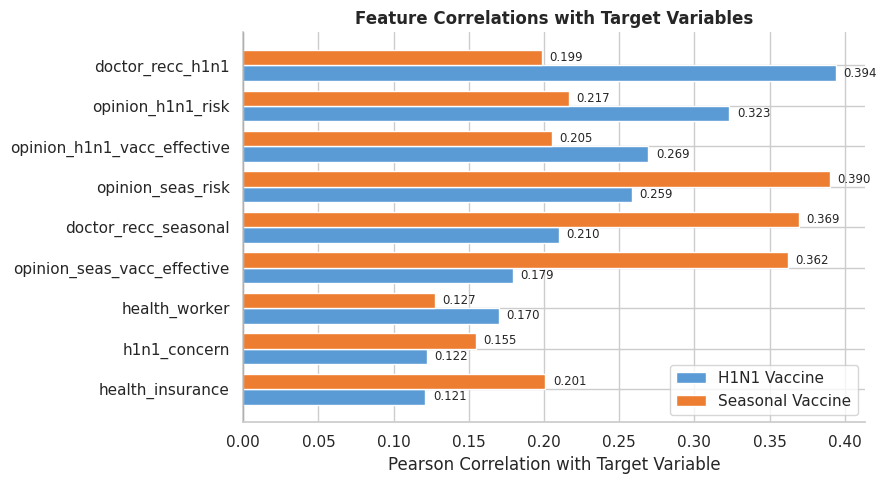

In [ ]:
# 3.3 Selected Feature vs Target Relationship
selected_features = [
    "doctor_recc_h1n1", "doctor_recc_seasonal",
    "h1n1_concern", "opinion_h1n1_vacc_effective", "opinion_h1n1_risk",
    "opinion_seas_vacc_effective", "opinion_seas_risk",
    "health_worker", "health_insurance"
]

# Correlation (numeric-friendly subset only)
corr_rows = []
for col in selected_features:
    if col in df.columns:
        # For ordinal/binary columns, Pearson can be used as a quick association signal
        x = df[col]
        corr_h1n1 = x.corr(df["h1n1_vaccine"])
        corr_seas = x.corr(df["seasonal_vaccine"])
        corr_rows.append([col, corr_h1n1, corr_seas])

corr_df = pd.DataFrame(corr_rows, columns=["feature", "corr_h1n1", "corr_seasonal"])
display(corr_df.sort_values(by="corr_h1n1", ascending=False))

# Correlation bar chart
corr_sorted = corr_df.sort_values("corr_h1n1", ascending=True).set_index("feature") # Set 'feature' as index after sorting to align with original plotting logic
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(corr_sorted))
w = 0.38
b1 = ax.barh(x - w/2, corr_sorted["corr_h1n1"],    height=w, color="#5B9BD5", label="H1N1 Vaccine")
b2 = ax.barh(x + w/2, corr_sorted["corr_seasonal"], height=w, color="#ED7D31", label="Seasonal Vaccine")
for bar in list(b1) + list(b2):
    v = bar.get_width()
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2, f"{v:.3f}", va="center", fontsize=8.5)
ax.set_yticks(x)
ax.set_yticklabels(corr_sorted.index)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with Target Variable")
ax.set_title("Feature Correlations with Target Variables", fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

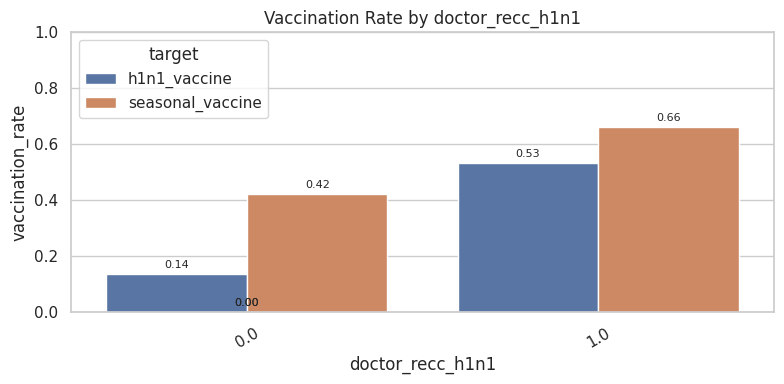

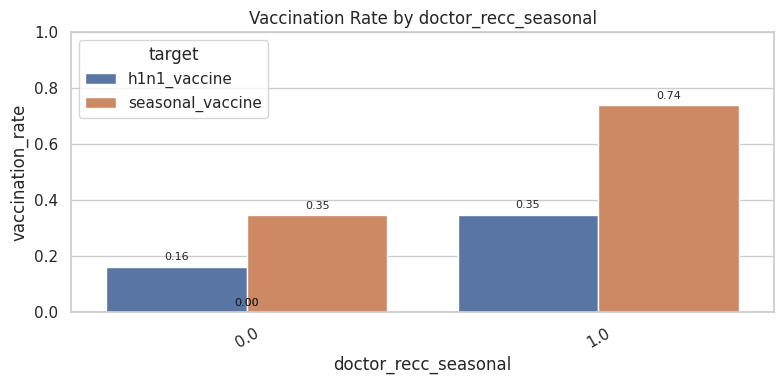

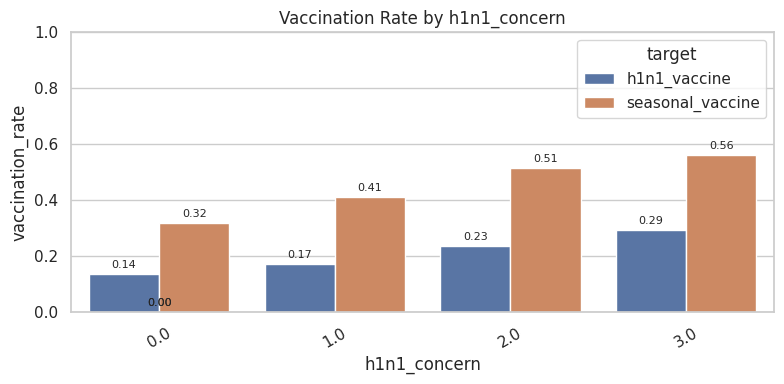

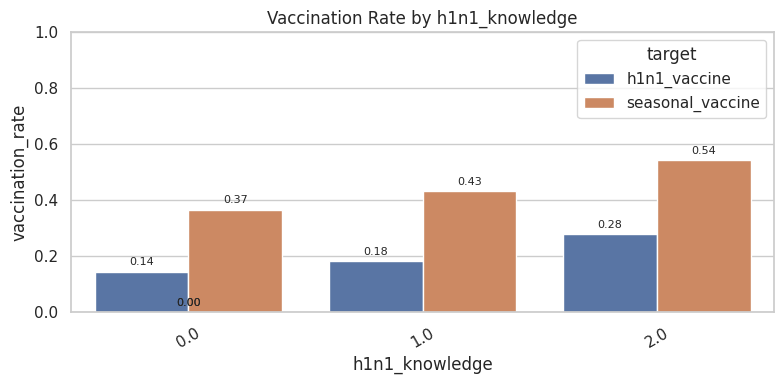

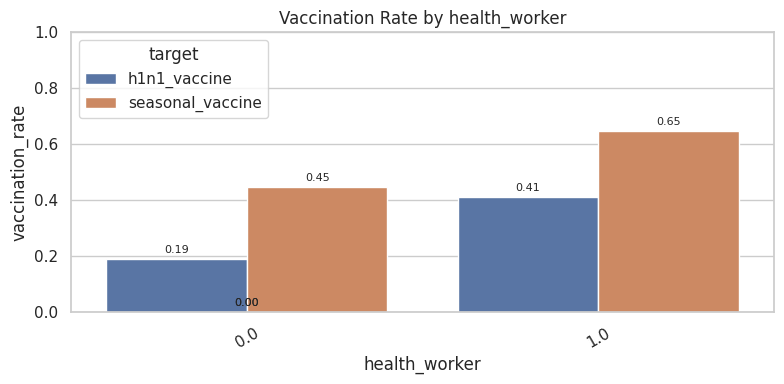

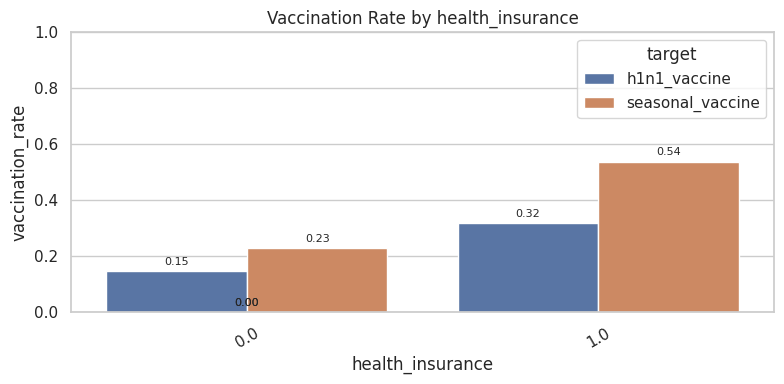

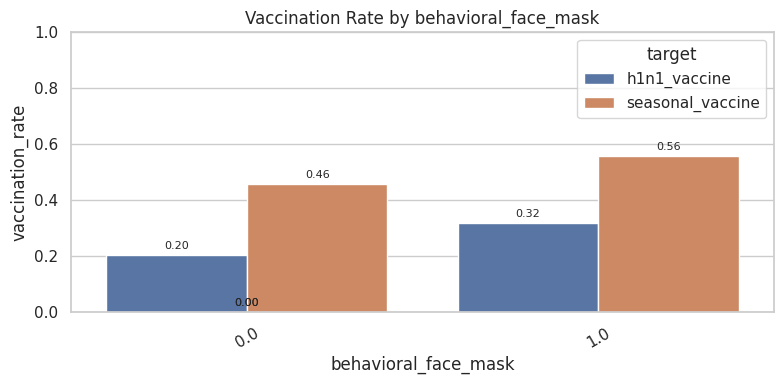

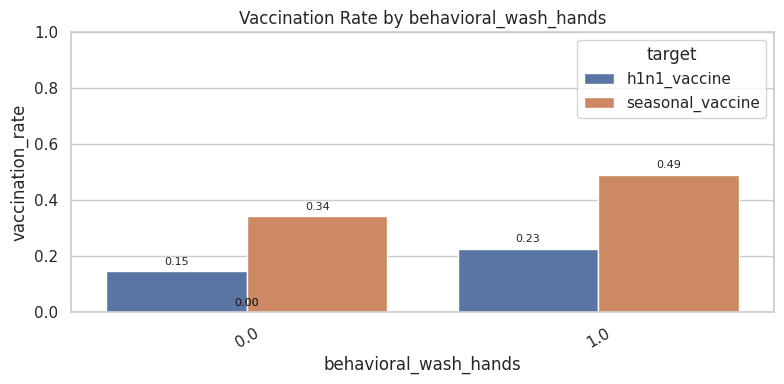

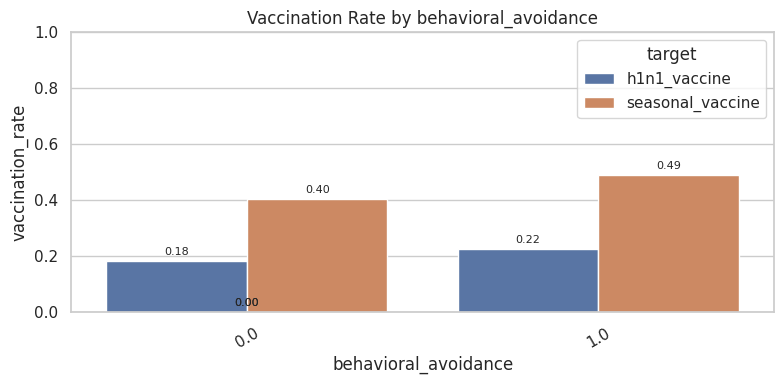

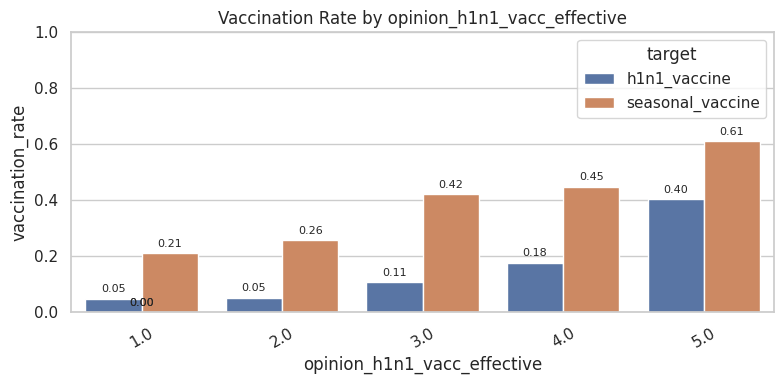

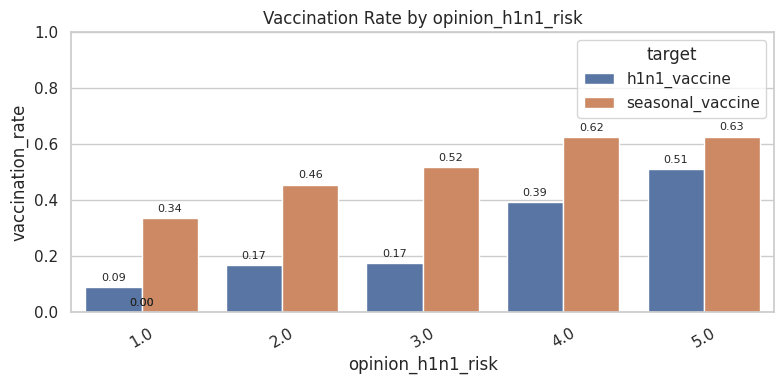

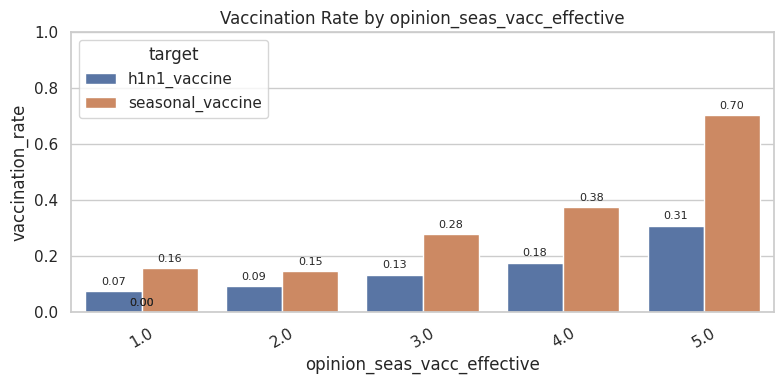

In [ ]:
# 3.4 Vaccination Rate by Feature Level

plot_features = [
    "doctor_recc_h1n1",
    "doctor_recc_seasonal",
    "h1n1_concern",
    "h1n1_knowledge",
    "health_worker",
    "health_insurance",
    "behavioral_face_mask",
    "behavioral_wash_hands",
    "behavioral_avoidance",
    "opinion_h1n1_vacc_effective",
    "opinion_h1n1_risk",
    "opinion_seas_vacc_effective"
]

for col in plot_features:
    if col not in df.columns:
        continue

    # Calculate average vaccination rates by feature level
    temp = df.groupby(col)[["h1n1_vaccine", "seasonal_vaccine"]].mean().reset_index()

    # Convert to long format for plotting
    temp_melt = temp.melt(id_vars=col, var_name="target", value_name="vaccination_rate")

    # Plot
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(data=temp_melt, x=col, y="vaccination_rate", hue="target")
    plt.title(f"Vaccination Rate by {col}")
    plt.ylim(0, 1)
    plt.xticks(rotation=30)

    # Add value labels on top of bars (2 decimal places)
    for p in ax.patches:
        height = p.get_height()
        if pd.notna(height):
            ax.annotate(f"{height:.2f}",
                        (p.get_x() + p.get_width() / 2, height),
                        ha="center", va="bottom",
                        fontsize=8, xytext=(0, 3),
                        textcoords="offset points")

    plt.tight_layout()
    plt.show()

#### Justification for Features Plotted above:-

I plotted 10+ features to show vaccination rate differences across a wider set of meaningful variables while keeping the analysis manageable. These features include doctor recommendation, risk perception, vaccine attitudes, preventive behaviors, and healthcare access/occupation.

This helps provide a clearer picture of how vaccination behavior changes across feature levels and complements the correlation analysis in Section above.

#### Observations from Vaccination Rate by Feature Levels

The bar plots show that vaccination rates vary across feature levels. In general, respondents with doctor recommendations, higher concern/risk perception, and stronger belief in vaccine effectiveness tend to have higher vaccination rates.

Protective behaviors (such as mask use and hand washing) and healthcare-related factors (such as being a health worker or having insurance) also appear to be associated with higher vaccine uptake.

## 4. Define Features/Targets and Train-Test Split

In [ ]:
# 4. Define Features/Targets and Train-Test Split

target_cols = ["h1n1_vaccine", "seasonal_vaccine"]
id_col = "respondent_id"

X = df.drop(columns=target_cols)
y_h1n1 = df["h1n1_vaccine"]
y_seasonal = df["seasonal_vaccine"]

# Train-test split (same split used for both targets)
X_train, X_test, y_h1n1_train, y_h1n1_test = train_test_split(
    X, y_h1n1, test_size=0.2, random_state=42, stratify=y_h1n1
)

# Align second target using same row indices
y_seasonal_train = y_seasonal.loc[X_train.index]
y_seasonal_test = y_seasonal.loc[X_test.index]

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_h1n1_train shape:", y_h1n1_train.shape)
print("y_h1n1_test shape :", y_h1n1_test.shape)
print("y_seasonal_train shape:", y_seasonal_train.shape)
print("y_seasonal_test shape :", y_seasonal_test.shape)

X_train shape: (21365, 36)
X_test shape : (5342, 36)
y_h1n1_train shape: (21365,)
y_h1n1_test shape : (5342,)
y_seasonal_train shape: (21365,)
y_seasonal_test shape : (5342,)


### Train-Test Split Strategy

The dataset is split into training and test sets so that model performance is evaluated on unseen data. This provides a better estimate of model generalization.

I use the same train-test split for both target variables (`h1n1_vaccine` and `seasonal_vaccine`) by aligning the second target (`seasonal_vaccine`) using row indices from the first split.

## 5. Preprocessing (Before Modeling)

In [ ]:
# 5. Preprocessing (Before Modeling)

# Keep respondent_id only in X_train/X_test for later reporting/subgroup analysis
# Remove it from modeling features
feature_cols = [c for c in X_train.columns if c != id_col]

X_train_model = X_train[feature_cols].copy()
X_test_model = X_test[feature_cols].copy()

numeric_cols = X_train_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train_model.select_dtypes(include=["object"]).columns.tolist()

print("Number of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

# Pipelines
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipe, numeric_cols),
    ("cat", cat_pipe, categorical_cols)
])

print("Preprocessor created successfully.")

Number of numeric columns: 23
Number of categorical columns: 12
Preprocessor created successfully.


#### Preprocessing Strategy (Done Before Modeling via Pipeline)

Preprocessing is defined before model training and applied inside a scikit-learn `Pipeline`, ensuring that transformations are learned from the training data and consistently applied to the test data.

The preprocessing steps are:
- Numerical features: median imputation + standardization
- Categorical features: most-frequent imputation + one-hot encoding

Using `ColumnTransformer` + `Pipeline` helps prevent data leakage and keeps the workflow consistent during model fitting and hyperparameter tuning.

## 6. Modelling ( Logistic Regression, Random Forest and Neural Network

In [ ]:
# Helper function to evaluate any pair of models (H1N1 + Seasonal)
def evaluate_two_targets(model_h1n1, model_seasonal, X_test_model, y_h1n1_test, y_seasonal_test, model_name="Model"):
    p_h1n1 = model_h1n1.predict_proba(X_test_model)[:, 1]
    p_seasonal = model_seasonal.predict_proba(X_test_model)[:, 1]

    auc_h1n1 = roc_auc_score(y_h1n1_test, p_h1n1)
    auc_seasonal = roc_auc_score(y_seasonal_test, p_seasonal)

    print(f"\n{'='*60}")
    print(f"{model_name} - Test Results")
    print(f"{'='*60}")
    print(f"{model_name} ROC-AUC (H1N1):    {auc_h1n1:.4f}")
    print(f"{model_name} ROC-AUC (Seasonal): {auc_seasonal:.4f}")

    result = {
        "h1n1_prob": p_h1n1,
        "seasonal_prob": p_seasonal,
        "auc_h1n1": auc_h1n1,
        "auc_seasonal": auc_seasonal
    }

    # Print what is stored in the dictionary
    print("\nReturned dictionary contents:")
    print(f"h1n1_prob      -> predicted probabilities for H1N1 vaccine on test set (length = {len(result['h1n1_prob'])})")
    print(f"seasonal_prob  -> predicted probabilities for Seasonal vaccine on test set (length = {len(result['seasonal_prob'])})")
    print(f"auc_h1n1       -> ROC-AUC for H1N1 = {result['auc_h1n1']:.4f}")
    print(f"auc_seasonal   -> ROC-AUC for Seasonal = {result['auc_seasonal']:.4f}")

    return result

In [ ]:
# 6.1 Logistic Regression (Baseline)

lr_h1n1 = Pipeline(steps=[
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=2000))
]).fit(X_train_model, y_h1n1_train)

lr_seasonal = Pipeline(steps=[
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=2000))
]).fit(X_train_model, y_seasonal_train)

# Immediate evaluation + print
lr_results = evaluate_two_targets(
    lr_h1n1, lr_seasonal,
    X_test_model, y_h1n1_test, y_seasonal_test,
    model_name="Logistic Regression"
)


Logistic Regression - Test Results
Logistic Regression ROC-AUC (H1N1):    0.8288
Logistic Regression ROC-AUC (Seasonal): 0.8552

Returned dictionary contents:
h1n1_prob      -> predicted probabilities for H1N1 vaccine on test set (length = 5342)
seasonal_prob  -> predicted probabilities for Seasonal vaccine on test set (length = 5342)
auc_h1n1       -> ROC-AUC for H1N1 = 0.8288
auc_seasonal   -> ROC-AUC for Seasonal = 0.8552


In [ ]:
# 6.2 Random Forest (with GridSearchCV)

pipe_rf = Pipeline(steps=[
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=1))
])

# Smaller/efficient grid (you can expand later if runtime allows)
rf_param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_leaf": [10, 20]
}

# ---- H1N1 model tuning ----
rf_grid_h1n1 = GridSearchCV(
    estimator=pipe_rf,
    param_grid=rf_param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=1,
    verbose=1
)
rf_grid_h1n1.fit(X_train_model, y_h1n1_train)

# ---- Seasonal model tuning ----
rf_grid_seasonal = GridSearchCV(
    estimator=pipe_rf,
    param_grid=rf_param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=1,
    verbose=1
)
rf_grid_seasonal.fit(X_train_model, y_seasonal_train)

# Best tuned models
rf_h1n1 = rf_grid_h1n1.best_estimator_
rf_seasonal = rf_grid_seasonal.best_estimator_

# Print best params + CV scores
print("\nBest RF params (H1N1):", rf_grid_h1n1.best_params_)
print("Best RF CV ROC AUC (H1N1):", round(rf_grid_h1n1.best_score_, 4))

print("\nBest RF params (Seasonal):", rf_grid_seasonal.best_params_)
print("Best RF CV ROC AUC (Seasonal):", round(rf_grid_seasonal.best_score_, 4))

# Evaluate immediately on test set (prints ROC-AUC + returned dictionary summary)
rf_results = evaluate_two_targets(
    rf_h1n1, rf_seasonal,
    X_test_model, y_h1n1_test, y_seasonal_test,
    model_name="Random Forest"
)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best RF params (H1N1): {'clf__max_depth': None, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 200}
Best RF CV ROC AUC (H1N1): 0.833

Best RF params (Seasonal): {'clf__max_depth': None, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 200}
Best RF CV ROC AUC (Seasonal): 0.8526

Random Forest - Test Results
Random Forest ROC-AUC (H1N1):    0.8285
Random Forest ROC-AUC (Seasonal): 0.8518

Returned dictionary contents:
h1n1_prob      -> predicted probabilities for H1N1 vaccine on test set (length = 5342)
seasonal_prob  -> predicted probabilities for Seasonal vaccine on test set (length = 5342)
auc_h1n1       -> ROC-AUC for H1N1 = 0.8285
auc_seasonal   -> ROC-AUC for Seasonal = 0.8518


In [ ]:
# 6.3 Neural Network / MLP (with GridSearchCV)

pipe_mlp = Pipeline(steps=[
    ("pre", preprocessor),
    ("clf", MLPClassifier(
        random_state=42,
        max_iter=300,
        early_stopping=True
    ))
])

# Efficient grid (rubric-compliant, faster than larger grid)
mlp_param_grid = {
    "clf__hidden_layer_sizes": [(64, 32), (128, 64)],
    "clf__alpha": [0.0001, 0.001],
    "clf__learning_rate_init": [0.001, 0.01]
    # activation kept default ('relu') for speed/stability
}

# ---- H1N1 model tuning ----
mlp_grid_h1n1 = GridSearchCV(
    estimator=pipe_mlp,
    param_grid=mlp_param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=1,
    verbose=1
)
mlp_grid_h1n1.fit(X_train_model, y_h1n1_train)

# ---- Seasonal model tuning ----
mlp_grid_seasonal = GridSearchCV(
    estimator=pipe_mlp,
    param_grid=mlp_param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=1,
    verbose=1
)
mlp_grid_seasonal.fit(X_train_model, y_seasonal_train)

# Best tuned models
mlp_h1n1 = mlp_grid_h1n1.best_estimator_
mlp_seasonal = mlp_grid_seasonal.best_estimator_

# Print best params + CV scores
print("\nBest MLP params (H1N1):", mlp_grid_h1n1.best_params_)
print("Best MLP CV ROC AUC (H1N1):", round(mlp_grid_h1n1.best_score_, 4))

print("\nBest MLP params (Seasonal):", mlp_grid_seasonal.best_params_)
print("Best MLP CV ROC AUC (Seasonal):", round(mlp_grid_seasonal.best_score_, 4))

# Evaluate immediately on test set (prints ROC-AUC + returned dictionary summary)
mlp_results = evaluate_two_targets(
    mlp_h1n1, mlp_seasonal,
    X_test_model, y_h1n1_test, y_seasonal_test,
    model_name="Neural Network (MLP)"
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best MLP params (H1N1): {'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (64, 32), 'clf__learning_rate_init': 0.001}
Best MLP CV ROC AUC (H1N1): 0.8341

Best MLP params (Seasonal): {'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (64, 32), 'clf__learning_rate_init': 0.01}
Best MLP CV ROC AUC (Seasonal): 0.8516

Neural Network (MLP) - Test Results
Neural Network (MLP) ROC-AUC (H1N1):    0.8324
Neural Network (MLP) ROC-AUC (Seasonal): 0.8529

Returned dictionary contents:
h1n1_prob      -> predicted probabilities for H1N1 vaccine on test set (length = 5342)
seasonal_prob  -> predicted probabilities for Seasonal vaccine on test set (length = 5342)
auc_h1n1       -> ROC-AUC for H1N1 = 0.8324
auc_seasonal   -> ROC-AUC for Seasonal = 0.8529


## 7. Generate Predictions and Evaluate Overall ROC AUC

In [ ]:
# 7. Compare Overall Model Performance (ROC AUC Summary Table)

# Collect all model outputs from earlier sections
preds = {
    "Logistic Regression": lr_results,
    "Random Forest": rf_results,
    "Neural Network (MLP)": mlp_results
}

results_df = pd.DataFrame([
    [
        model_name,
        out["auc_h1n1"],
        out["auc_seasonal"],
        (out["auc_h1n1"] + out["auc_seasonal"]) / 2
    ]
    for model_name, out in preds.items()
], columns=["Model", "ROC_AUC_H1N1", "ROC_AUC_Seasonal", "Mean_ROC_AUC"])

results_df = results_df.sort_values("Mean_ROC_AUC", ascending=False).reset_index(drop=True)

display(results_df)

best_model_name = results_df.loc[0, "Model"]
print("Best overall model based on Mean ROC AUC:", best_model_name)

,Model,ROC_AUC_H1N1,ROC_AUC_Seasonal,Mean_ROC_AUC
0,Neural Network (MLP),0.832371,0.852864,0.842617
1,Logistic Regression,0.828793,0.855183,0.841988
2,Random Forest,0.828516,0.851789,0.840152


Best overall model based on Mean ROC AUC: Neural Network (MLP)


### Overall Model Performance Comparison (ROC AUC)

This table summarizes the test-set ROC AUC for each model on both targets (`h1n1_vaccine` and `seasonal_vaccine`) and the mean ROC AUC, which is the assignment’s overall evaluation criterion.

The model with the highest mean ROC AUC is considered the best overall model for this dataset.

#### 7.1 ROC Curves for All Models

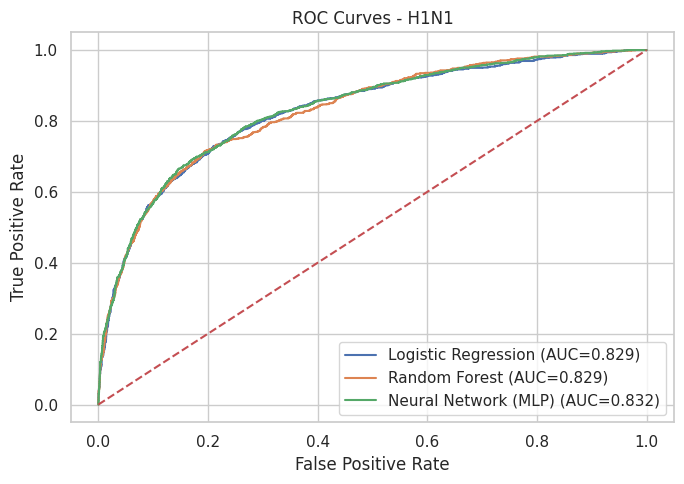

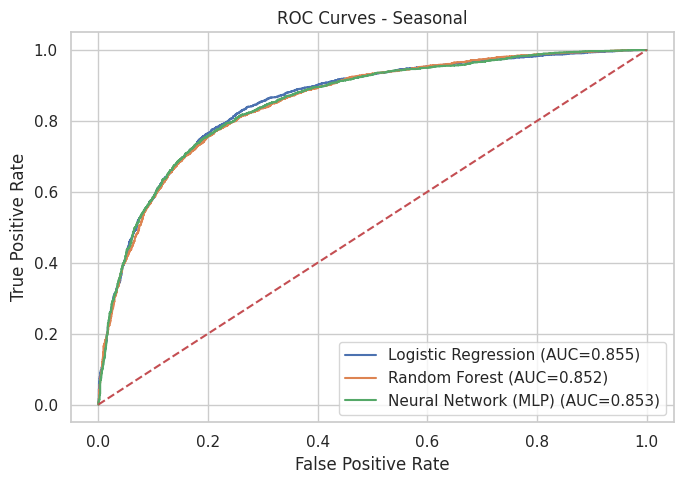

In [ ]:
# 7.1 ROC Curves for All Models

for target_name, y_true, prob_key in [
    ("H1N1", y_h1n1_test, "h1n1_prob"),
    ("Seasonal", y_seasonal_test, "seasonal_prob")
]:
    plt.figure(figsize=(7, 5))

    for model_name, out in preds.items():
        fpr, tpr, _ = roc_curve(y_true, out[prob_key])
        auc_val = roc_auc_score(y_true, out[prob_key])
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_val:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves - {target_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Observations from ROC Curves

The ROC curves visualize model performance across all probability thresholds. Curves that stay closer to the top-left corner indicate better discrimination between vaccinated and non-vaccinated respondents.

These plots complement the ROC AUC summary table and help verify whether the best-performing model remains strong across thresholds.

## 8. Subgroup Performance Evaluation

In [ ]:
# 8. Subgroup Performance Evaluation (Required by Rubric)

def safe_auc(y_true, y_prob):
    # ROC AUC is undefined if only one class is present
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)

subgroup_rows = []

# Evaluate across required subgroup columns
for group_col in ["age_group", "race", "sex"]:
    if group_col not in X_test.columns:
        continue

    temp = X_test[[group_col]].copy()
    temp["y_h1n1"] = y_h1n1_test.values
    temp["y_seasonal"] = y_seasonal_test.values

    # Add probabilities from each model
    for model_name, out in preds.items():
        temp[f"{model_name}_h1n1_prob"] = out["h1n1_prob"]
        temp[f"{model_name}_seasonal_prob"] = out["seasonal_prob"]

    # Compute subgroup-level AUCs
    for grp_value, gdf in temp.groupby(group_col, dropna=False):
        n = len(gdf)

        for model_name in preds.keys():
            auc_h = safe_auc(gdf["y_h1n1"], gdf[f"{model_name}_h1n1_prob"])
            auc_s = safe_auc(gdf["y_seasonal"], gdf[f"{model_name}_seasonal_prob"])

            subgroup_rows.append({
                "group_col": group_col,
                "group_value": grp_value,
                "n": n,
                "model": model_name,
                "auc_h1n1": auc_h,
                "auc_seasonal": auc_s,
                "mean_auc": np.nanmean([auc_h, auc_s]) if not (pd.isna(auc_h) and pd.isna(auc_s)) else np.nan
            })

subgroup_df = pd.DataFrame(subgroup_rows)

print("Subgroup evaluation table created.")
display(subgroup_df.head(34))
print("Total subgroup rows:", subgroup_df.shape[0])

Subgroup evaluation table created.


,group_col,group_value,n,model,auc_h1n1,auc_seasonal,mean_auc
0,age_group,18 - 34 Years,1058,Logistic Regression,0.797293,0.821121,0.809207
1,age_group,18 - 34 Years,1058,Random Forest,0.807144,0.827425,0.817284
2,age_group,18 - 34 Years,1058,Neural Network (MLP),0.803254,0.822910,0.813082
3,age_group,35 - 44 Years,771,Logistic Regression,0.842142,0.831979,0.837060
4,age_group,35 - 44 Years,771,Random Forest,0.835710,0.819086,0.827398
5,age_group,35 - 44 Years,771,Neural Network (MLP),0.835917,0.835379,0.835648
6,age_group,45 - 54 Years,1035,Logistic Regression,0.848833,0.850607,0.849720
7,age_group,45 - 54 Years,1035,Random Forest,0.855369,0.852170,0.853770
8,age_group,45 - 54 Years,1035,Neural Network (MLP),0.857032,0.846290,0.851661
9,age_group,55 - 64 Years,1065,Logistic Regression,0.866881,0.844783,0.855832


Total subgroup rows: 33


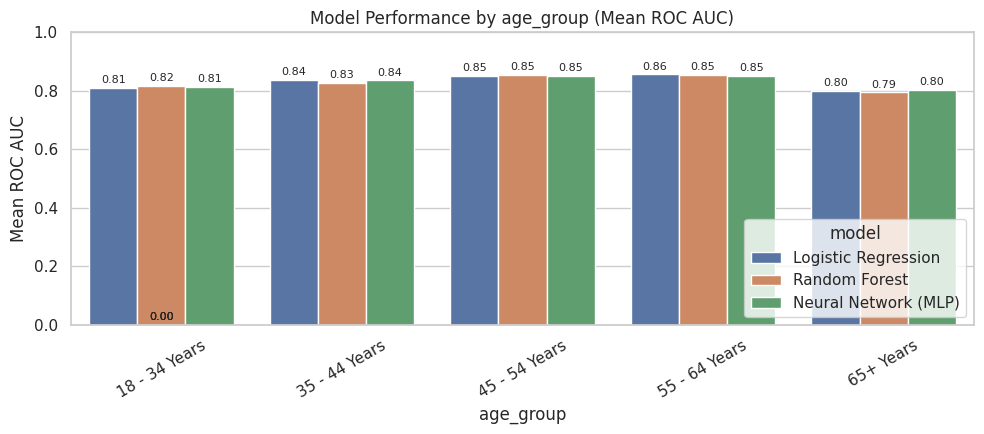

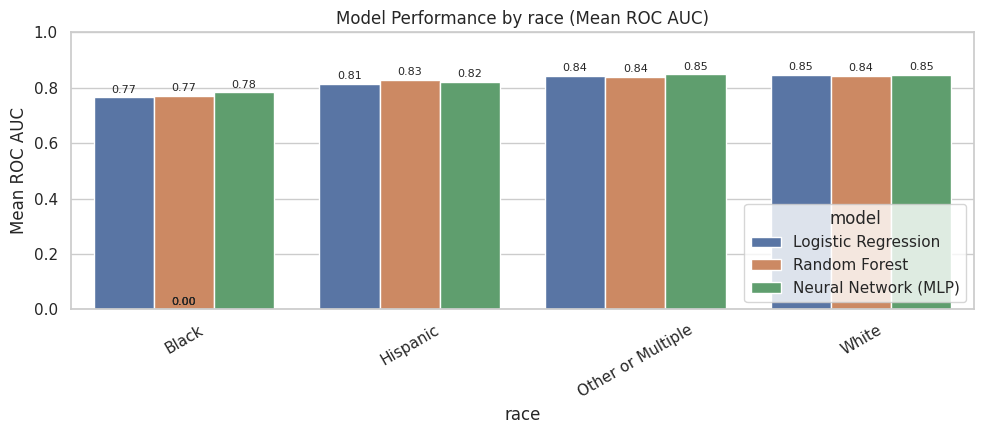

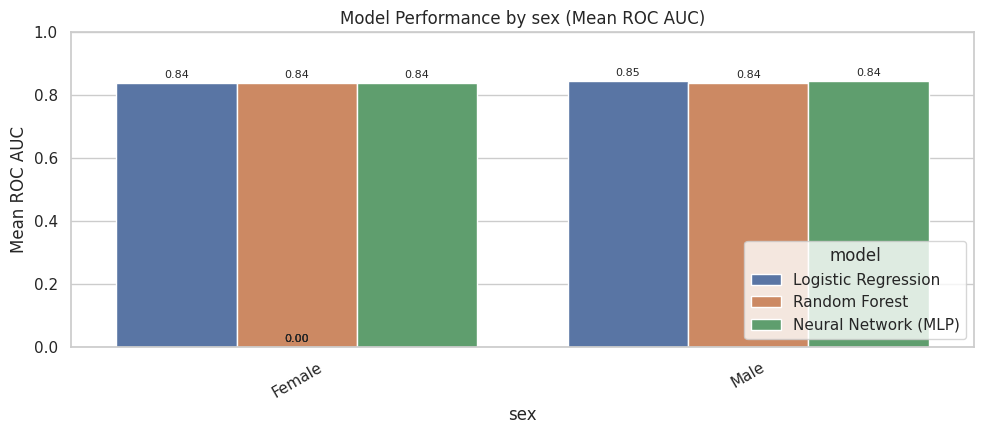

In [ ]:
# Simple plots for the three subgroups (Mean ROC AUC)

for gcol in ["age_group", "race", "sex"]:
    sub = subgroup_df[subgroup_df["group_col"] == gcol].copy()
    sub = sub.dropna(subset=["mean_auc"])

    if sub.empty:
        print(f"No data available for {gcol}")
        continue

    plt.figure(figsize=(10, 4.5))
    ax = sns.barplot(data=sub, x="group_value", y="mean_auc", hue="model")
    plt.title(f"Model Performance by {gcol} (Mean ROC AUC)")
    plt.xlabel(gcol)
    plt.ylabel("Mean ROC AUC")
    plt.ylim(0, 1)
    plt.xticks(rotation=30)

    # Add labels on bars
    for p in ax.patches:
        h = p.get_height()
        if pd.notna(h):
            ax.annotate(f"{h:.2f}",
                        (p.get_x() + p.get_width()/2, h),
                        ha="center", va="bottom", fontsize=8,
                        xytext=(0, 2), textcoords="offset points")

    plt.tight_layout()
    plt.show()

### Observations from Subgroup Performance (age_group, race, sex)

#### 1) Overall subgroup stability
- The three models perform **very similarly overall**, with only small differences in mean ROC AUC across most subgroups.
- This is consistent with the overall test-set comparison, where **Neural Network (MLP)** had the highest mean ROC AUC, but only by a small margin over Logistic Regression.

#### 2) Age-group differences (largest variation among the three subgroup variables)
- Subgroup performance varies more across **age_group** than across `sex`.
- The **best mean ROC AUC by age group** ranges from about **0.804 (65+ Years)** to **0.856 (55–64 Years)**, indicating noticeable variation across age segments.
- For **18–34 Years**, **Random Forest** performs best (mean AUC ≈ **0.817**).
- For **35–44 Years** and **55–64 Years**, **Logistic Regression** is best (mean AUC ≈ **0.837** and **0.856**, respectively).
- For **45–54 Years**, **Random Forest** performs best (mean AUC ≈ **0.854**).
- For **65+ Years**, **Neural Network (MLP)** performs best (mean AUC ≈ **0.804**), but this age group still shows lower performance than most other age groups across models.

#### 3) Race-group differences
- Performance variation across **race** is also visible, with the **best mean ROC AUC** ranging from about **0.783 (Black)** to **0.848 (Other or Multiple)**.
- **Neural Network (MLP)** performs best for **Black** (mean AUC ≈ **0.783**) and **Other or Multiple** (mean AUC ≈ **0.848**).
- **Random Forest** performs best for **Hispanic** (mean AUC ≈ **0.829**).
- **Logistic Regression** performs best for **White** (mean AUC ≈ **0.847**).
- The lower subgroup AUC for some race categories may be related to subgroup sample size and/or class imbalance, so these differences should be interpreted carefully.

#### 4) Sex-group differences (very stable)
- Performance across **sex** is quite stable compared with `age_group` and `race`.
- For **Female**, **Neural Network (MLP)** performs best (mean AUC ≈ **0.840**).
- For **Male**, **Logistic Regression** performs best (mean AUC ≈ **0.845**).
- The gap between the best-performing sex subgroups is small (about **0.005** in mean AUC), suggesting relatively consistent performance across `Female` and `Male`.

#### 5) Practical interpretation
- No single model dominates every subgroup.
- Although **MLP** is the best overall model by mean ROC AUC, **Logistic Regression** and **Random Forest** outperform it in some demographic subgroups.
- Therefore, subgroup evaluation provides useful additional evidence beyond the overall score and helps assess model consistency across population segments.

In [ ]:
import joblib
import os

# Export best models (MLP - highest mean ROC-AUC: 0.8426)
joblib.dump(mlp_h1n1, "model_h1n1.pkl")
joblib.dump(mlp_seasonal, "model_seasonal.pkl")

print("model_h1n1.pkl size:", round(os.path.getsize("model_h1n1.pkl")/1024/1024, 2), "MB")
print("model_seasonal.pkl size:", round(os.path.getsize("model_seasonal.pkl")/1024/1024, 2), "MB")
print("Done!")

model_h1n1.pkl size: 0.22 MB
model_seasonal.pkl size: 0.22 MB
Done!
